# Train DS

## Load ds

In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')

print('Rows:', len(df))
print('Columns:', list(df.columns))

Rows: 891
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


## Explore ds


In [19]:
print('Head:')
display(df.head())
print('\nTail:')
display(df.tail())

Head:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Tail:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### Numeric summary

In [20]:
display(df.select_dtypes(include=[np.number]).describe())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Categorical summary

In [21]:
display(df.select_dtypes(exclude=[np.number]).describe())



,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [22]:
# Missing values
print('\nMissing values per column:')
display(df.isna().sum().sort_values(ascending=False))




Missing values per column:


,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [23]:
# Data types
display(df.dtypes)

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


### distributions using histograms


Survived distribution
Max: 1


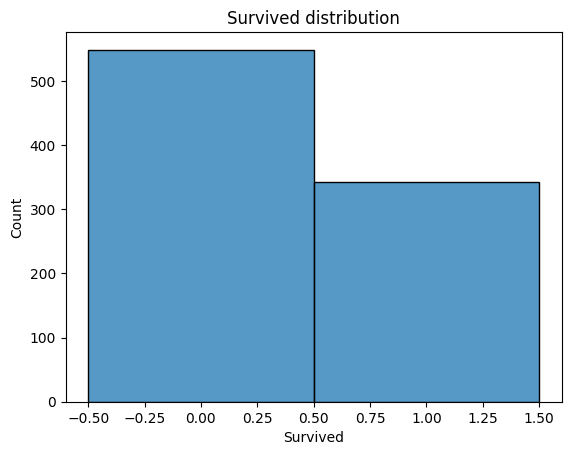


Pclass distribution
Max: 3


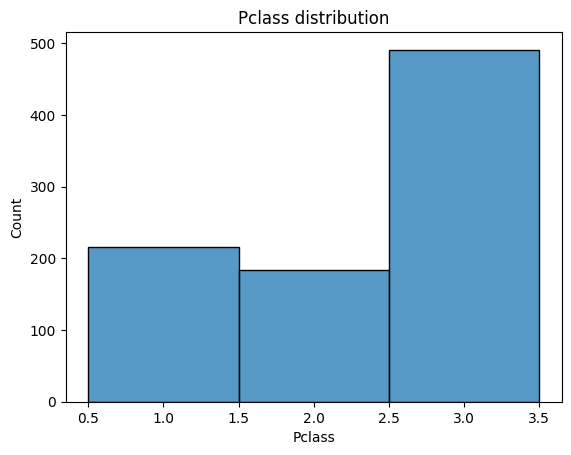


Age distribution
Max: 80.0


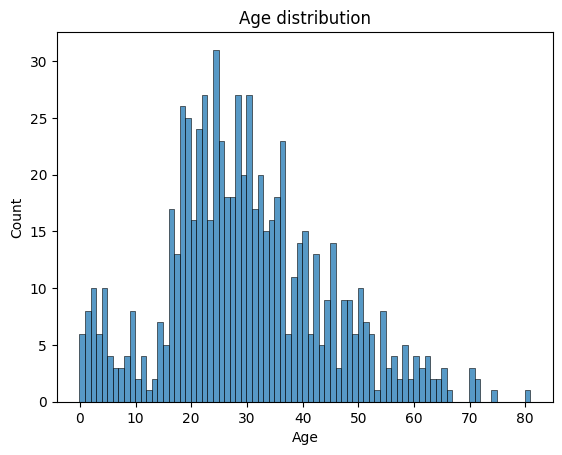


SibSp distribution
Max: 8


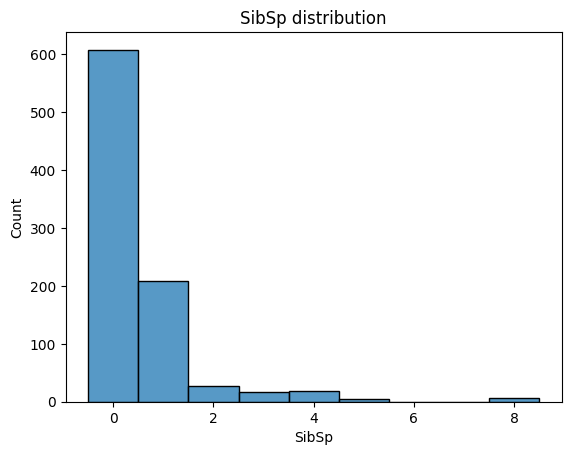


Parch distribution
Max: 6


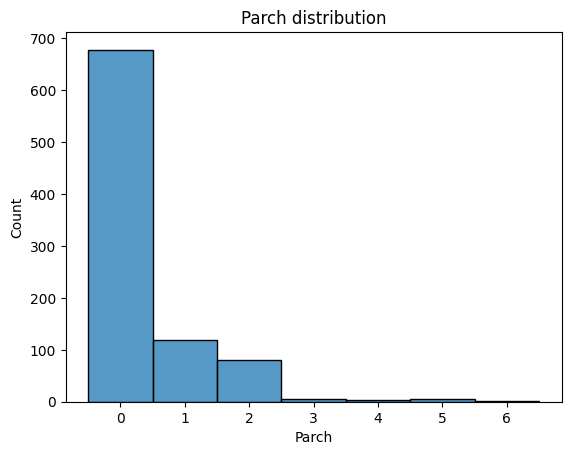


Fare distribution
Max: 512.3292


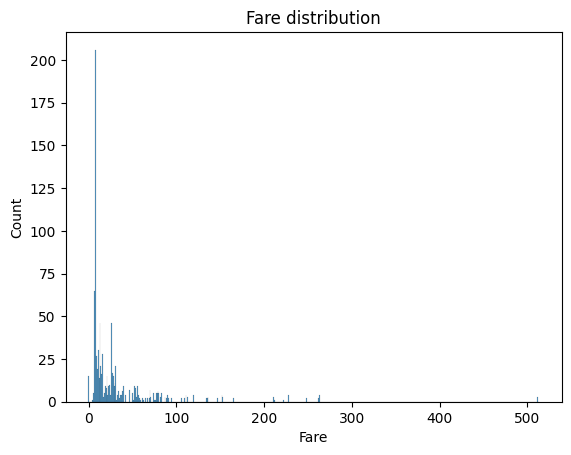

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=[np.number]).columns
for c in num_cols:
  if c == 'PassengerId':
    continue
  print(f'\n{c} distribution')
  cleaned = df[c].dropna()
  max_val = cleaned.max()
  print('Max:', max_val)
  if max_val > 10.0:
    sns.histplot(cleaned, bins=10, discrete=True)
  else:
    sns.histplot(cleaned, bins=max_val, discrete=True)
  plt.title(f'{c} distribution')
  plt.show()

## Handle missing values

In [25]:
missing_before = df.isna().sum()
print('Missing before:')
display(missing_before[missing_before>0].sort_values(ascending=False))

df_mv = df.copy()

# Numeric
num_cols = df_mv.select_dtypes(include=[np.number]).columns
for c in num_cols:
  if df_mv[c].isna().any():
    med = df_mv[c].median()
    df_mv[c] = df_mv[c].fillna(med)

# Categorical
cat_cols = df_mv.select_dtypes(exclude=[np.number]).columns
for c in cat_cols:
  if df_mv[c].isna().any():
    mode_val = df_mv[c].mode(dropna=True)[0]
    df_mv[c] = df_mv[c].fillna(mode_val)

print('\nMissing after:')
display(df_mv.isna().sum().sort_values(ascending=False))

Missing before:


,0
Cabin,687
Age,177
Embarked,2



Missing after:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Detect and handle outliers
**Columns that may contain outliers**: SibSp, Parch, Fare; based on numeric distributions.

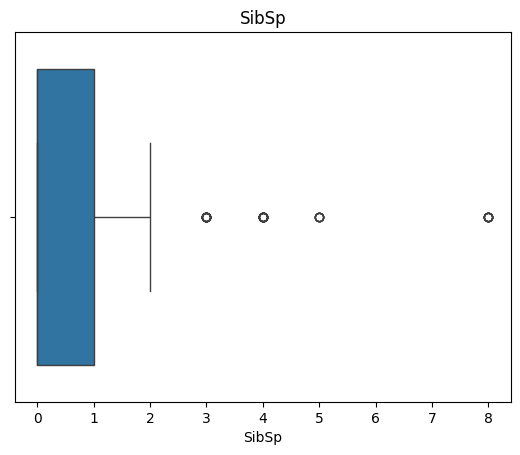

min of outliers: 3
count of outliers: 46


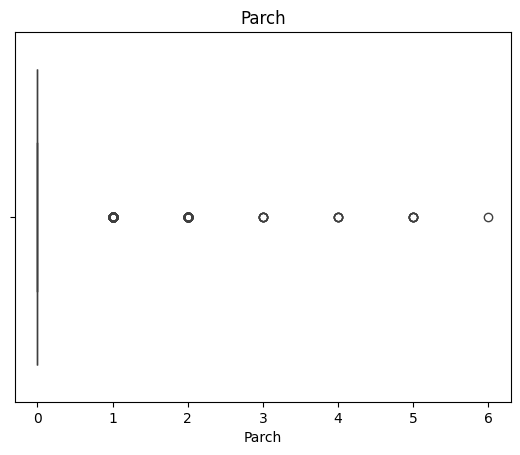

min of outliers: 1
count of outliers: 213


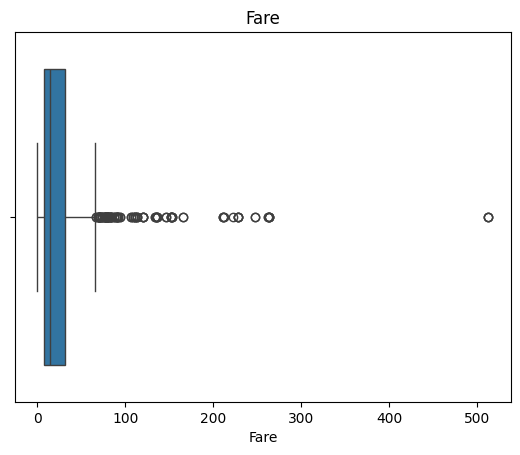

min of outliers: 66.6
count of outliers: 116


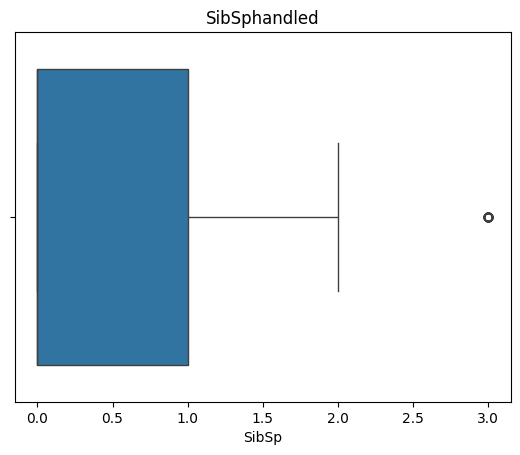

min of outliers: 3
count of outliers: 46


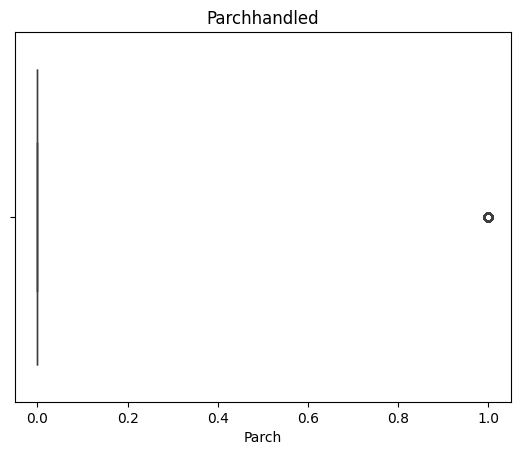

min of outliers: 1
count of outliers: 213


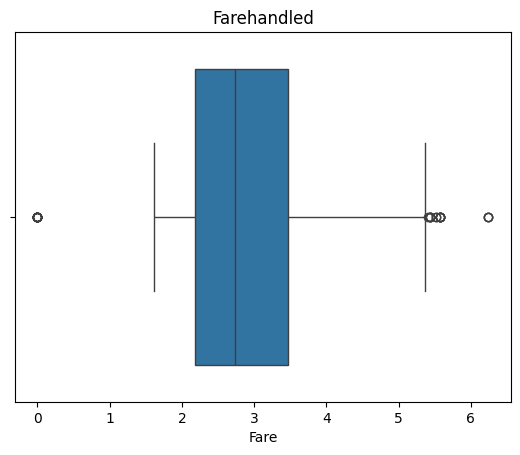

min of outliers: 0.0
count of outliers: 31


In [26]:
df_ol = df_mv.copy()
cols = ["SibSp", "Parch", "Fare"]

def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

for c in cols:
    sns.boxplot(x=df_ol[c])
    plt.title(c)
    plt.show()
    print(f"min of outliers: {detect_outliers(df_ol[c]).min()}")
    print(f"count of outliers: {detect_outliers(df_ol[c]).count()}")

# SibSp / Parch -> cap la 5
min_outlier = detect_outliers(df_ol["SibSp"]).min()
df_ol.loc[df_ol["SibSp"] > min_outlier, "SibSp"] = min_outlier
min_outlier = detect_outliers(df_ol["Parch"]).min()
df_ol.loc[df_ol["Parch"] > min_outlier, "Parch"] = min_outlier

# Fare -> log transform
df_ol["Fare"] = np.log1p(df_ol["Fare"])


for c in cols:
    sns.boxplot(x=df_ol[c])
    plt.title(c + "handled")
    plt.show()
    print(f"min of outliers: {detect_outliers(df_ol[c]).min()}")
    print(f"count of outliers: {detect_outliers(df_ol[c]).count()}")


## Feature engineering

In [27]:
import re

feature_df = df_ol.copy()

# += Family size
feature_df["FamilySize"] = feature_df["SibSp"] + feature_df["Parch"] + 1

# += Title
def extract_title(name):
    # Modified regex to capture titles with spaces
    match = re.search(r",\s*([A-Za-z\s]+)\.", name)
    if match:
        # Remove leading/trailing spaces from the captured title
        return match.group(1).strip()
    return None

feature_df["Title"] = feature_df["Name"].apply(extract_title)
print("Counts of each unique title:")
display(feature_df["Title"].value_counts())

# map titles
title_map = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs",
}

common_titles = ["Mr","Miss","Mrs","Master"]

def categorize_title(t):
    t = title_map.get(t, t)
    if t in common_titles:
        return t
    else:
        return "Rare"

feature_df["TitleGroup"] = feature_df["Title"].apply(categorize_title)
print("Counts of each unique title group:")
display(feature_df["TitleGroup"].value_counts())


Counts of each unique title:


,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


Counts of each unique title group:


,count
TitleGroup,
Mr,517
Miss,185
Mrs,126
Master,40
Rare,23


## Feature selection

In [30]:
feature_df = feature_df.drop(columns=['Cabin', 'SibSp', 'Parch', 'Title'])
display(feature_df.head())

KeyError: "['Cabin', 'SibSp', 'Parch'] not found in axis"

## Correlation matrix

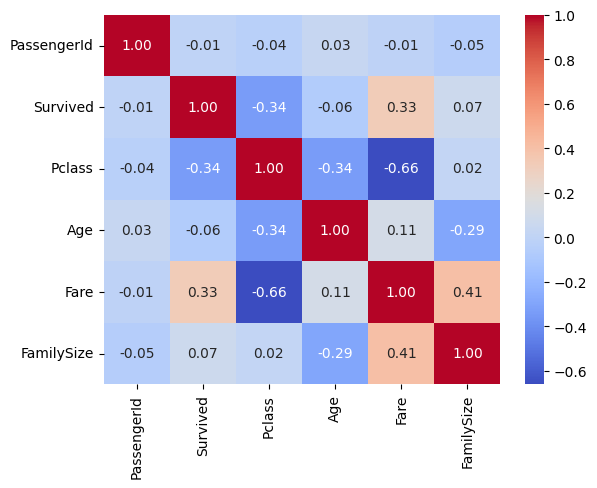

In [29]:
cor_df = feature_df.select_dtypes(include=[np.number])
corr_matrix = cor_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

# No Pipeline

## Encode categorical variables

In [ ]:
df_enc = df_ol.copy()

df_enc = pd.get_dummies(df_enc, columns=['Embarked'])
df_enc["Sex"] = df_enc["Sex"].map({"male": 0, "female": 1})

display(df_enc.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,2.110213,B96 B98,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,4.280593,C85,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,2.188856,B96 B98,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,3.990834,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,2.202765,B96 B98,False,False,True


## Scale numeric features
I chose to standardize only "Age" and "Fare" because they are continuous variables with a wide range of values, while SibSp, Parch, and Pclass are discrete categorical-like variables with small, already comparable ranges that don't benefit from standardization.

In [ ]:
from sklearn.preprocessing import StandardScaler

scale_df = df_enc.copy()
scaler_std = StandardScaler()
columns_to_scale = ['Age', 'Fare']

scale_df[columns_to_scale] = scaler_std.fit_transform(df_enc[columns_to_scale])


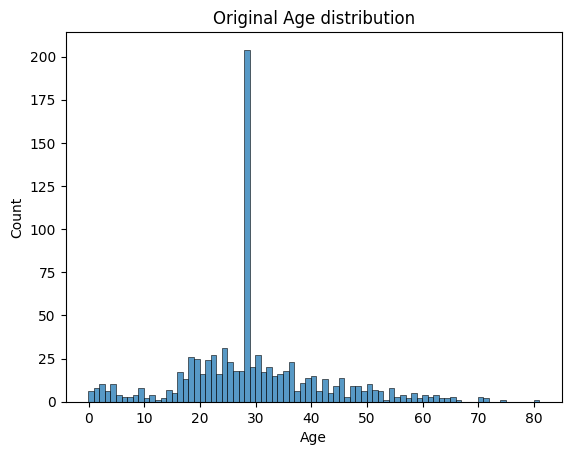

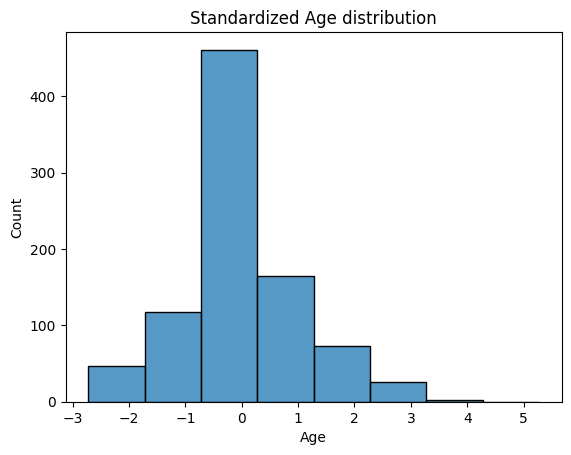

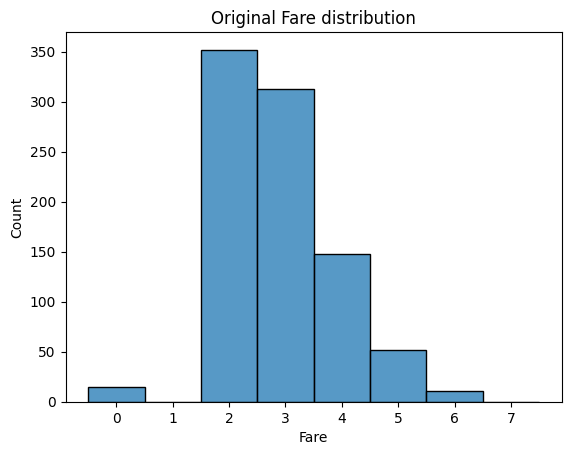

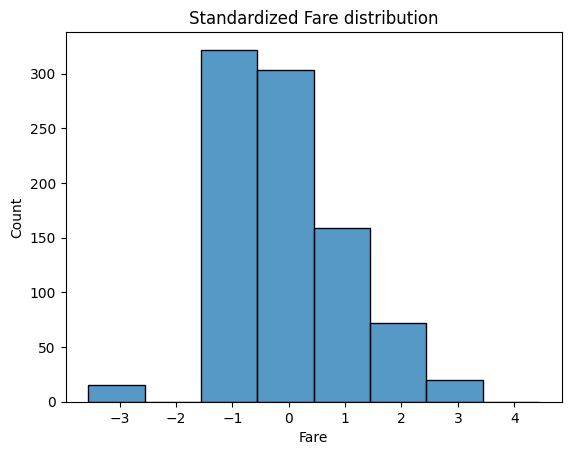

In [ ]:
sns.histplot(df_enc["Age"], bins=30, discrete=True)
plt.title("Original Age distribution")
plt.show()

sns.histplot(scale_df["Age"], bins=30, discrete=True)
plt.title("Standardized Age distribution")
plt.show()

sns.histplot(df_enc["Fare"], bins=30, discrete=True)
plt.title("Original Fare distribution")
plt.show()

sns.histplot(scale_df["Fare"], bins=30, discrete=True)
plt.title("Standardized Fare distribution")
plt.show()

# Pipeline

In [33]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# Split
X = feature_df[['Fare', 'Pclass', 'Sex', 'TitleGroup', 'Age']]
y = feature_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Preprocessing steps
numeric_features = ['Fare', 'Pclass', 'Age']
numeric_transformer = StandardScaler()

categorical_features = ['Sex', 'TitleGroup']
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Pipeline with preprocessing + model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [34]:
# Train the model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Fare', 'Pclass', 'Age']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Sex', 'TitleGroup'])])),
                ('regressor', LinearRegression())])

In [35]:
# Predict
y_pred = pipeline.predict(X_test)
print("Predictions:", y_pred)

Predictions: [ 0.4583274   0.23885091  0.08655033  0.75785652  0.58540713  0.87720611
  0.56497377  0.07637336  0.58947599  0.91757109  0.36992024  0.03720821
  0.53810157  0.06811483  0.22386583  0.91416602  0.35995716  0.564755
  0.14332409  0.35000046  0.07846248  0.39242966  0.58306302  0.08324896
  0.05681421  0.48109618  0.2802497   0.23407509  0.49334729  0.5585608
  0.08867174  0.57722488  0.40127738  0.56553515  0.09029636  0.05892791
  0.39785101  0.56497377  0.89123925  0.07029508  0.21390631  0.07069149
  0.06987784  0.07069629  0.62427217  0.0612827   0.08796569  0.07712341
  0.08088808  0.30888657  0.59155434  0.92784838  0.01718648  0.80611944
 -0.00485222  0.89329889  0.23680905  0.90845661  0.70921166  0.58299457
  0.08491999  0.75584688  0.82635265  0.40523789  0.07069629  0.78786036
  0.21390631  0.06831006  0.09464651  0.93211609  0.83043636  0.86456632
  0.40589999  0.84938621  0.08061814  0.03888804  0.55986914  0.89649733
  0.7140596   0.62475036  0.05788577  0.8

Accuracy: 0.7985074626865671


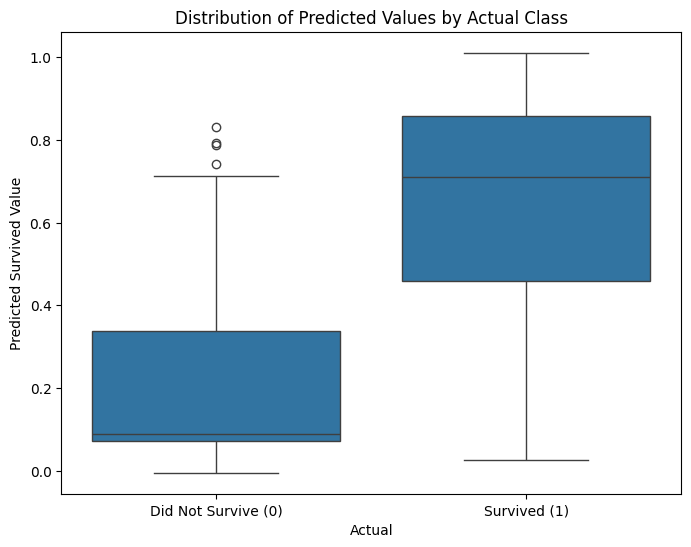

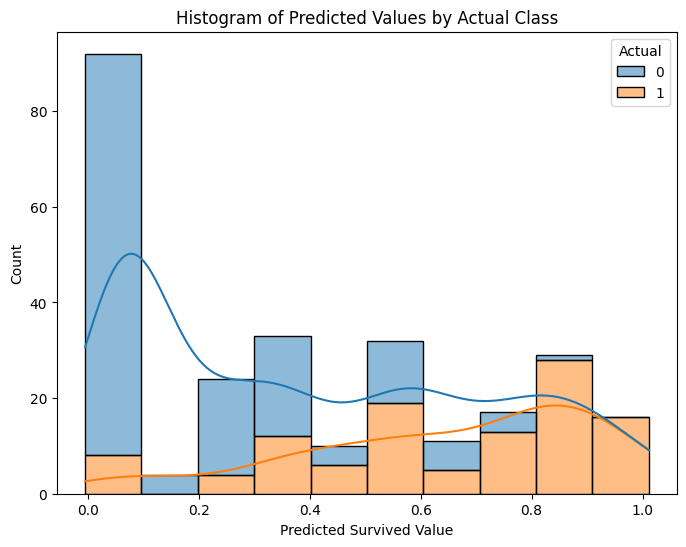

In [36]:
from sklearn.metrics import accuracy_score

y_pred_binary = (y_pred > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Accuracy: {accuracy}")

plot_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

plt.figure(figsize=(8, 6))
sns.boxplot(x='Actual', y='Predicted', data=plot_df)
plt.title('Distribution of Predicted Values by Actual Class')
plt.xticks([0, 1], ['Did Not Survive (0)', 'Survived (1)'])
plt.ylabel('Predicted Survived Value')
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(data=plot_df, x='Predicted', hue='Actual', multiple='stack', kde=True)
plt.title('Histogram of Predicted Values by Actual Class')
plt.xlabel('Predicted Survived Value')
plt.show()

# Test DS

In [69]:
import pandas as pd
import numpy as np

df = pd.read_csv('test.csv')

print('Rows:', len(df))
print('Columns:', list(df.columns))

Rows: 418
Columns: ['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


## Explore ds


In [70]:
print('Head:')
display(df.head())
print('\nTail:')
display(df.tail())

Head:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S



Tail:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


### Numeric summary

In [71]:
display(df.select_dtypes(include=[np.number]).describe())

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


### Categorical summary

In [72]:
display(df.select_dtypes(exclude=[np.number]).describe())



,Name,Sex,Ticket,Cabin,Embarked
count,418,418,418,91,418
unique,418,2,363,76,3
top,"Peter, Master. Michael J",male,PC 17608,B57 B59 B63 B66,S
freq,1,266,5,3,270


In [73]:
# Missing values
print('\nMissing values per column:')
display(df.isna().sum().sort_values(ascending=False))




Missing values per column:


,0
Cabin,327
Age,86
Fare,1
Name,0
Pclass,0
PassengerId,0
Sex,0
Parch,0
SibSp,0
Ticket,0


In [74]:
# Data types
display(df.dtypes)

,0
PassengerId,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
Cabin,object


### distributions using histograms


Pclass distribution
Max: 3


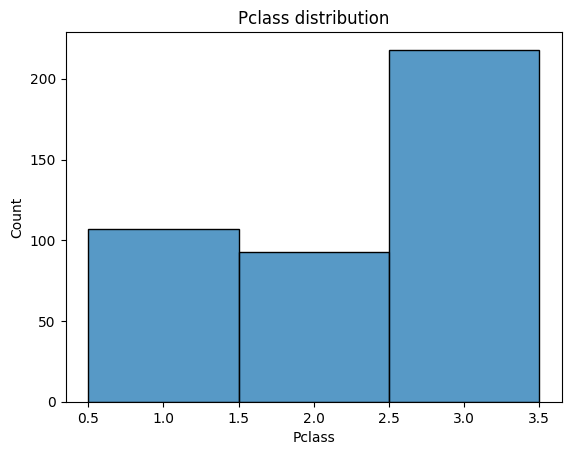


Age distribution
Max: 76.0


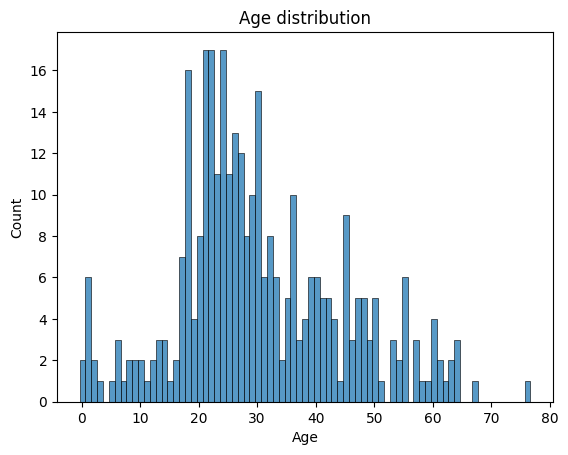


SibSp distribution
Max: 8


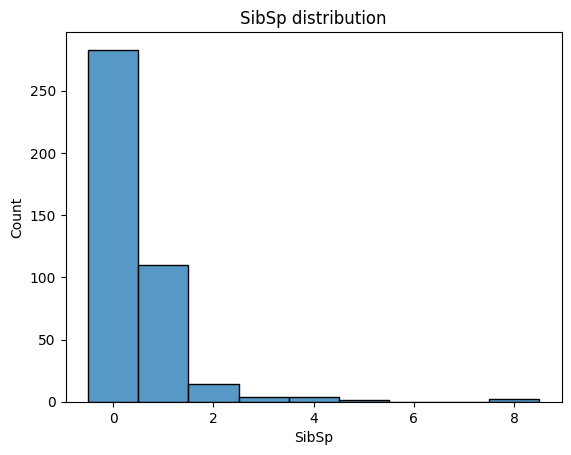


Parch distribution
Max: 9


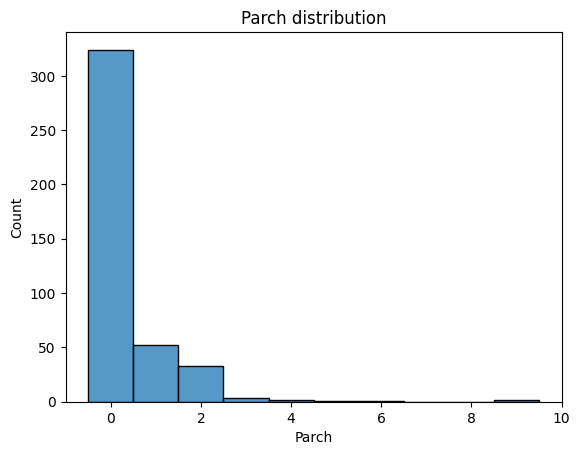


Fare distribution
Max: 512.3292


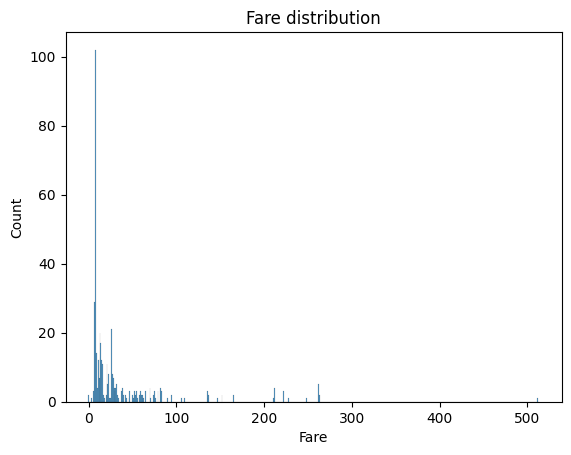

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=[np.number]).columns
for c in num_cols:
  if c == 'PassengerId':
    continue
  print(f'\n{c} distribution')
  cleaned = df[c].dropna()
  max_val = cleaned.max()
  print('Max:', max_val)
  if max_val > 10.0:
    sns.histplot(cleaned, bins=10, discrete=True)
  else:
    sns.histplot(cleaned, bins=max_val, discrete=True)
  plt.title(f'{c} distribution')
  plt.show()

## Handle missing values

In [76]:
missing_before = df.isna().sum()
print('Missing before:')
display(missing_before[missing_before>0].sort_values(ascending=False))

df_mv = df.copy()

# Numeric
num_cols = df_mv.select_dtypes(include=[np.number]).columns
for c in num_cols:
  if df_mv[c].isna().any():
    med = df_mv[c].median()
    df_mv[c] = df_mv[c].fillna(med)

# Categorical
cat_cols = df_mv.select_dtypes(exclude=[np.number]).columns
for c in cat_cols:
  if df_mv[c].isna().any():
    mode_val = df_mv[c].mode(dropna=True)[0]
    df_mv[c] = df_mv[c].fillna(mode_val)

print('\nMissing after:')
display(df_mv.isna().sum().sort_values(ascending=False))

Missing before:


,0
Cabin,327
Age,86
Fare,1



Missing after:


,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,0


## Detect and handle outliers
**Columns that may contain outliers**: SibSp, Parch, Fare; based on numeric distributions.

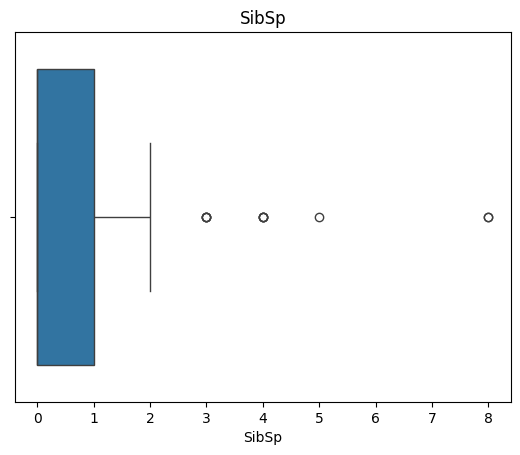

min of outliers: 3
count of outliers: 11


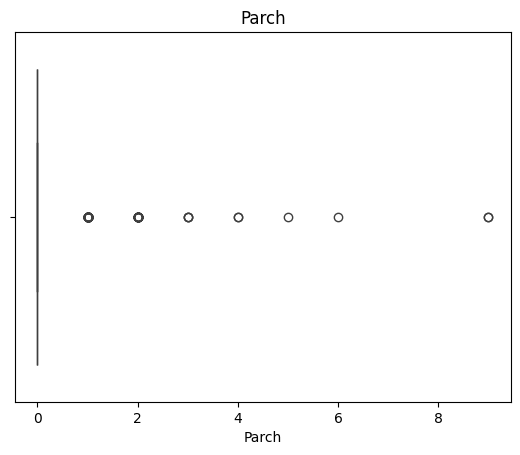

min of outliers: 1
count of outliers: 94


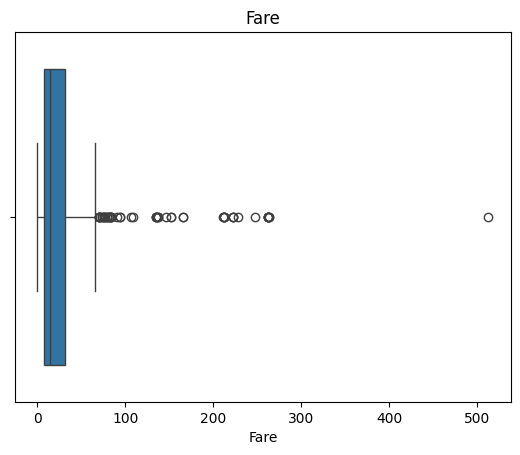

min of outliers: 69.55
count of outliers: 55


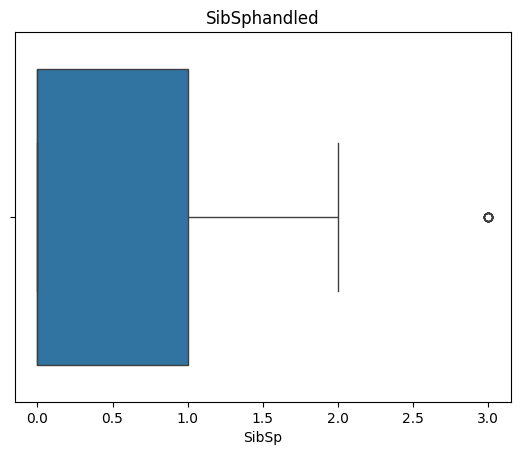

min of outliers: 3
count of outliers: 11


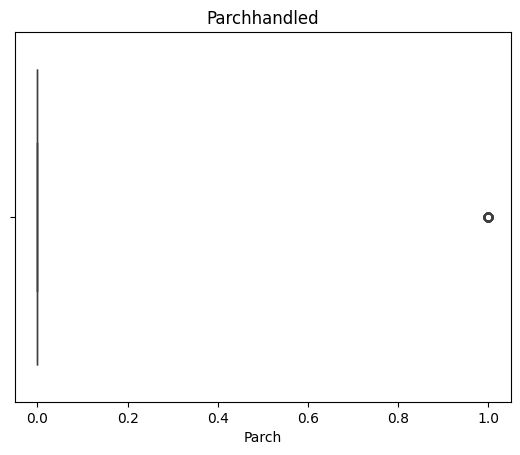

min of outliers: 1
count of outliers: 94


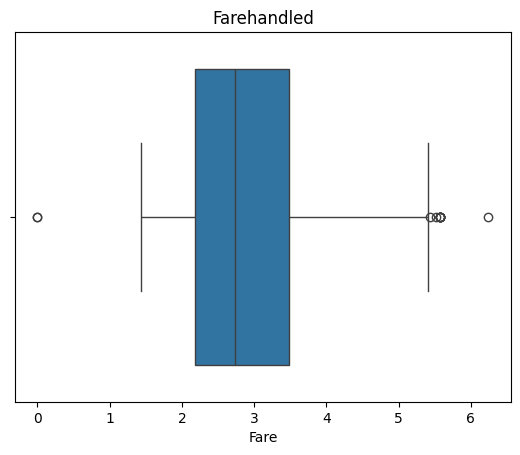

min of outliers: 0.0
count of outliers: 12


In [77]:
df_ol = df_mv.copy()
cols = ["SibSp", "Parch", "Fare"]

def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

for c in cols:
    sns.boxplot(x=df_ol[c])
    plt.title(c)
    plt.show()
    print(f"min of outliers: {detect_outliers(df_ol[c]).min()}")
    print(f"count of outliers: {detect_outliers(df_ol[c]).count()}")

# SibSp / Parch -> cap la 5
min_outlier = detect_outliers(df_ol["SibSp"]).min()
df_ol.loc[df_ol["SibSp"] > min_outlier, "SibSp"] = min_outlier
min_outlier = detect_outliers(df_ol["Parch"]).min()
df_ol.loc[df_ol["Parch"] > min_outlier, "Parch"] = min_outlier

# Fare -> log transform
df_ol["Fare"] = np.log1p(df_ol["Fare"])


for c in cols:
    sns.boxplot(x=df_ol[c])
    plt.title(c + "handled")
    plt.show()
    print(f"min of outliers: {detect_outliers(df_ol[c]).min()}")
    print(f"count of outliers: {detect_outliers(df_ol[c]).count()}")


## Encode categorical variables

In [78]:
df_enc = df_ol.copy()

df_enc = pd.get_dummies(df_enc, columns=['Embarked'])
df_enc["Sex"] = df_enc["Sex"].map({"male": 0, "female": 1})

display(df_enc.head())

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,2.178064,B57 B59 B63 B66,False,True,False
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,2.079442,B57 B59 B63 B66,False,False,True
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,2.369075,B57 B59 B63 B66,False,True,False
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,2.268252,B57 B59 B63 B66,False,False,True
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,2.586824,B57 B59 B63 B66,False,False,True


## Scale numeric features
I chose to standardize only "Age" and "Fare" because they are continuous variables with a wide range of values, while SibSp, Parch, and Pclass are discrete categorical-like variables with small, already comparable ranges that don't benefit from standardization.

In [79]:
from sklearn.preprocessing import StandardScaler

scale_df = df_enc.copy()
scaler_std = StandardScaler()
columns_to_scale = ['Age', 'Fare']

scale_df[columns_to_scale] = scaler_std.fit_transform(df_enc[columns_to_scale])


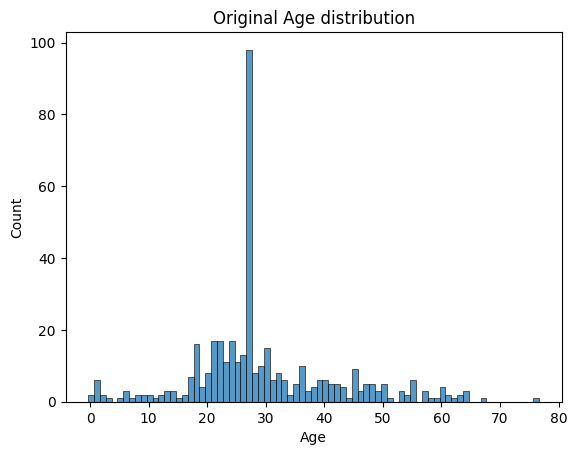

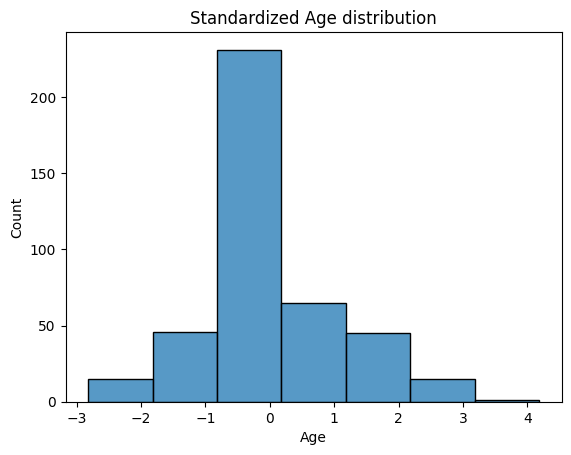

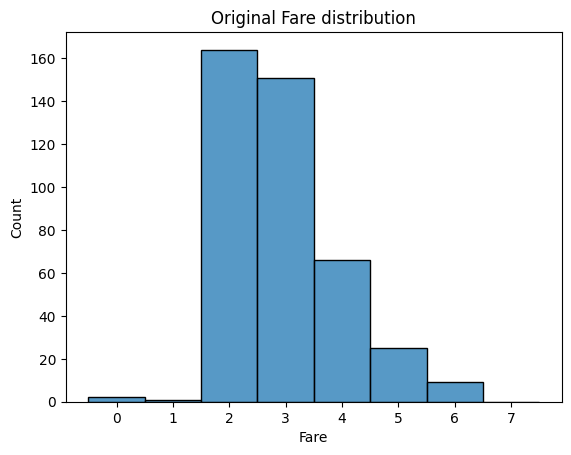

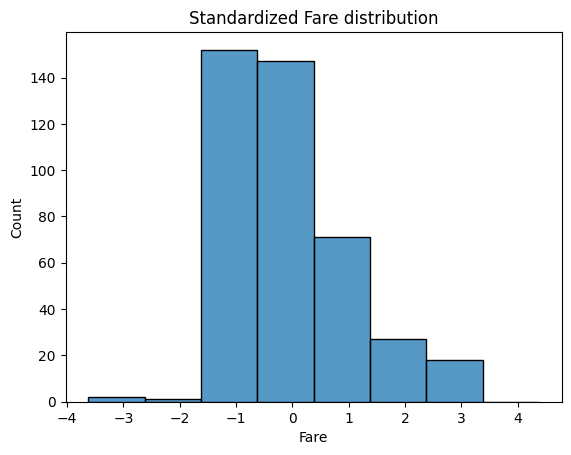

In [80]:
sns.histplot(df_enc["Age"], bins=30, discrete=True)
plt.title("Original Age distribution")
plt.show()

sns.histplot(scale_df["Age"], bins=30, discrete=True)
plt.title("Standardized Age distribution")
plt.show()

sns.histplot(df_enc["Fare"], bins=30, discrete=True)
plt.title("Original Fare distribution")
plt.show()

sns.histplot(scale_df["Fare"], bins=30, discrete=True)
plt.title("Standardized Fare distribution")
plt.show()

## Feature engineering

In [81]:
feature_df = scale_df.copy()

feature_df["FamilySize"] = feature_df["SibSp"] + feature_df["Parch"] + 1


## Feature selection / importance

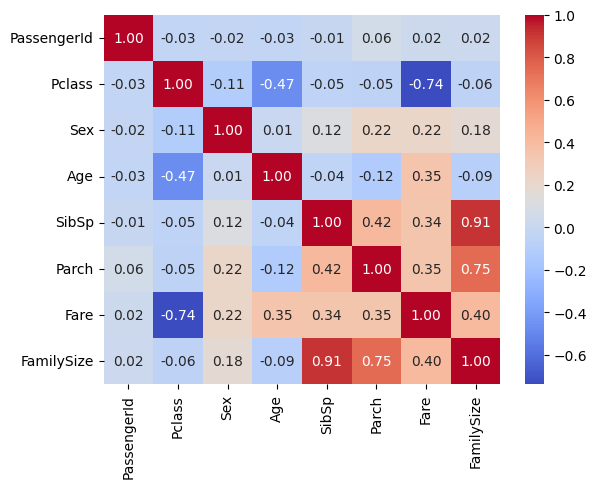

In [82]:
# correlation matrix only for numeric columns
cor_df = feature_df.select_dtypes(include=[np.number])
corr_matrix = cor_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

# Predict Test DS

In [40]:
# Predict on the test dataset
X_test_df = feature_df[['Fare', 'Pclass', 'Sex', 'TitleGroup', 'Age']]
y_pred_test = pipeline.predict(X_test_df)

In [91]:
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_test_binary = (y_pred_test > 0.5).astype(int)

# Display the predictions
print("Predictions on test.csv data:")
print(y_pred_test_binary)

Predictions on test.csv data:
[0 1 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 1 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 0 1
 1 0 0 0 0 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 0 1 0
 1 0 0 1 0 1 0 0 0 0 0 0 1 1 1 0 1 0 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0
 1 1 1 1 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0
 0 0 1 0 0 1 0 0 1 1 0 1 1 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1
 0 1 0 1 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 0 0 1 0 1 0 0 0 0 1 1 0 1 0 1 0 1 0
 1 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 1
 0 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 1 1 0 1 1 0
 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 0 0 0 0
 0 1 1 1 1 1 0 1 0 0 0]
